# Behaviour Model: Predicting Late Settlement from Payment History

## PROJECT TITLE: Ensemble Machine Learning for Mitigating Payment Paralysis in Kenyan SMEs. 
 This notebook trains the model the prototype uses for clients with at least three settled invoices.
 Dataset: Zindi Loan Default Prediction Challenge, CC BY-SA 4.0. 
 https://zindi.africa/competitions/loan-default-prediction-challenge

An SME selling on credit needs to know which clients are likely to pay late before it hands over goods.
The question here is, given how a client has settled before, what is the chance they settle the next one late?
Success means accurate probabilities that sort clients into tiers, where High-tier clients really do settle late far more often than others.
The tier cut-offs are fixed now, before any results: Low is below 10%, Medium ranges from 10% to below 30%, High 30% and above.

# Install Dependencies and Import Required Libraries

- pandas and numpy handle the tables.
- scikit-learn provides the models, pipelines, tuning and scores.
- imbalanced-learn provides SMOTE.
- SHAP explains the model.
- joblib saves the model.

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             precision_score, recall_score, f1_score, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

## Set the Environment Variables

one place for folder paths and the random seed, so every run gives the same result and every file lands in the same place.

In [3]:
SEED = 42
RAW = '../data/raw/'
MODELS = '../models/'
REPORTS = '../reports/'
FIGS = REPORTS + 'figures/'
for folder in (MODELS, FIGS):
    os.makedirs(folder, exist_ok=True)
np.random.seed(SEED)
print('Environment ready')

Environment ready


# Load the Data

- trainprevloans.csv holds earlier loans with due dates and actual closing dates.
- trainperf.csv holds the July 2017 loans we predict.
- The demographics file is deliberately not loaded, because a supplier would not know a client's age, education or GPS location.
- Note that the data is from Nigeria. The page lists Tanzania, but the banks and GPS points are Nigerian.

In [4]:
prev = pd.read_csv(RAW + 'trainprevloans.csv',
                   parse_dates=['approveddate', 'creationdate', 'closeddate', 'firstduedate', 'firstrepaiddate'])
perf = pd.read_csv(RAW + 'trainperf.csv', parse_dates=['approveddate', 'creationdate'])
print('Earlier loans:', prev.shape)
print('July 2017 loans:', perf.shape)
prev.head()

Earlier loans: (18183, 12)
July 2017 loans: (4368, 10)


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40,2016-08-15 17:22:32,10000.0,13000.0,30,2016-09-01 16:06:48,NaN,2016-09-14,2016-09-01 15:51:43
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07,2017-04-28 17:38:53,10000.0,13000.0,30,2017-05-28 14:44:49,NaN,2017-05-30,2017-05-26 00:00:00
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25,2017-03-05 09:56:19,20000.0,23800.0,30,2017-04-26 22:18:56,NaN,2017-04-04,2017-04-26 22:03:47
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55,2017-04-09 17:25:42,10000.0,11500.0,15,2017-04-24 01:35:52,NaN,2017-04-24,2017-04-24 00:48:43
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57,2017-06-17 08:29:50,10000.0,11500.0,15,2017-07-14 21:18:43,NaN,2017-07-03,2017-07-14 21:08:35


## Identify the Target Variable

- Zindi defines Bad as "did not settle the loan on time". For the July loans that label is given.
- For the earlier loans we apply the same definition ourselves. A loan is late if it was closed after its final due date, which is the approval date plus the loan term.
- 1 means settled late and 0 means settled on time.
- In the dashboard the same rule reads: an invoice is late if its payment date is after its due date.

In [5]:
# The July loans come with the answer: Bad means the loan was not settled on time.
perf['target'] = (perf.good_bad_flag == 'Bad').astype(int)

# For earlier loans we work out the same answer: was the loan closed after its final due date?
prev['final_due'] = prev.approveddate.dt.normalize() + pd.to_timedelta(prev.termdays, unit='D')
prev['days_late'] = (prev.closeddate.dt.normalize() - prev.final_due).dt.days
prev['target'] = (prev.days_late > 0).astype(int)

print(f'Earlier loans settled late: {prev.target.mean():.1%}')
print(f'July loans not settled on time: {perf.target.mean():.1%}')

Earlier loans settled late: 24.4%
July loans not settled on time: 21.8%


# Initial Exploratory Data Analysis

**Measures of Frequency**

How often each loan term and loan number appears and the balance of the July target. 
Imbalance (about one late for every three to four on time) is the thread that shapes later choices.

In [6]:
print('How often each value appears\n')
for col in ['termdays', 'loannumber']:
    print(prev[col].value_counts().sort_index().head(12), '\n')
print(perf.good_bad_flag.value_counts())

How often each value appears

termdays
15     6115
30    11045
60      993
90       30
Name: count, dtype: int64 

loannumber
1     4344
2     2969
3     2300
4     1860
5     1535
6     1288
7     1036
8      817
9      637
10     446
11     333
12     223
Name: count, dtype: int64 

good_bad_flag
Good    3416
Bad      952
Name: count, dtype: int64


**Measures of Central Tendency**

Includes averages, middle values and spread of the numeric columns.

In [7]:
prev[['loanamount', 'totaldue', 'termdays', 'loannumber', 'days_late']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
loanamount,18183.0,16501.24,9320.55,3000.0,10000.0,10000.0,20000.0,60000.0
totaldue,18183.0,19573.20,10454.25,3450.0,11500.0,13000.0,24500.0,68100.0
termdays,18183.0,26.69,10.95,15.0,15.0,30.0,30.0,90.0
loannumber,18183.0,4.19,3.25,1.0,2.0,3.0,6.0,26.0
days_late,18183.0,-2.79,11.19,-75.0,-6.0,-2.0,0.0,351.0


The median days late is -2, so most loans close a couple of days early. 
- The maximum of 351 days shows a few extreme cases.

**Measures of Distribution**

- Skewness above 1 means a long right tail.
- Kurtosis far above 0 means extreme values are common.
- days_late is extremely skewed and that is one reason we use tree models which are not bothered by skew.

In [8]:
shape = pd.DataFrame({
    'skewness': prev[['loanamount', 'termdays', 'loannumber', 'days_late']].skew(),
    'kurtosis': prev[['loanamount', 'termdays', 'loannumber', 'days_late']].kurt()}).round(2)
shape

,skewness,kurtosis
loanamount,1.29,0.81
termdays,1.46,3.97
loannumber,1.30,1.86
days_late,4.43,106.18


**Measures of Relationship**


Does the late rate change with the loan term or with how many loans a customer has taken? This is a first look at whether history matters.

In [9]:
print('Late rate by loan term (days):')
print(prev.groupby('termdays').target.agg(['count', 'mean']).round(3))
print('\nLate rate by how many loans the customer had taken:')
print(prev.groupby(prev.loannumber.clip(upper=8)).target.agg(['count', 'mean']).round(3))

Late rate by loan term (days):
          count   mean
termdays              
15         6115  0.243
30        11045  0.256
60          993  0.127
90           30  0.000

Late rate by how many loans the customer had taken:
            count   mean
loannumber              
1            4344  0.240
2            2969  0.291
3            2300  0.270
4            1860  0.253
5            1535  0.249
6            1288  0.227
7            1036  0.209
8            2851  0.194


- 60 and 90 day loans settle late less often.
- Customers on their 8th or later loan settle late less often (about 19%) than customers on their 2nd (about 29%).
- So experience with the lender matters.

**Basic Visualisation**

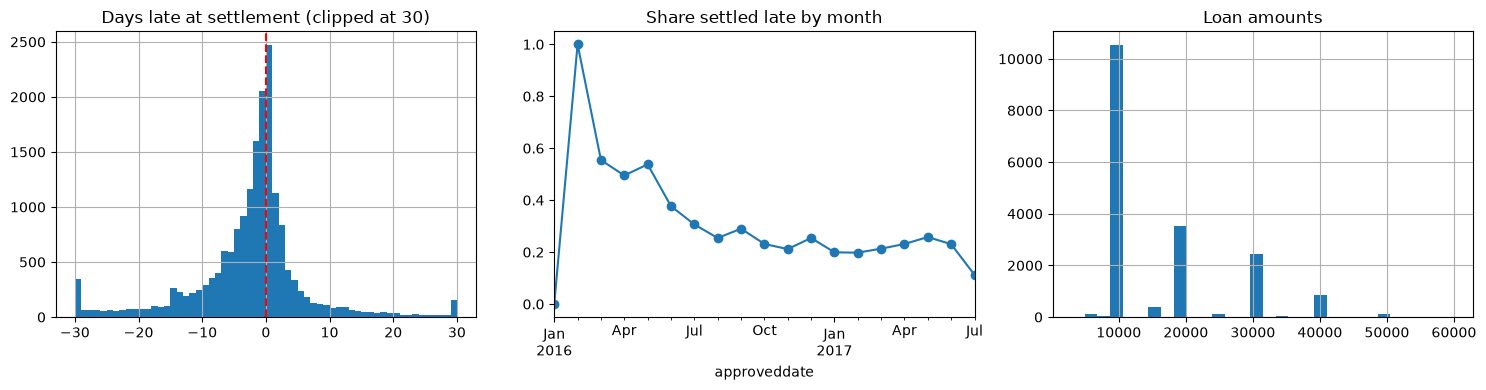

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
prev.days_late.clip(-30, 30).hist(bins=60, ax=axes[0])
axes[0].set_title('Days late at settlement (clipped at 30)')
axes[0].axvline(0, color='red', linestyle='--')
prev.groupby(prev.approveddate.dt.to_period('M')).target.mean().plot(ax=axes[1], marker='o')
axes[1].set_title('Share settled late by month')
prev.loanamount.hist(bins=30, ax=axes[2])
axes[2].set_title('Loan amounts')
plt.tight_layout()
plt.savefig(FIGS + 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

Most loans close just before or on the due date. The monthly late rate is fairly steady, which supports a time split.

## Feature Engineering: Historical Client Behaviour

The model learns from how each client behaved before. For every loan we look back only at the same customer's earlier loans that were already closed before this loan was approved and summarise them. Loans that closed later are excluded, because the system could not have known about them at that moment. Doing this before the split is safe, because each row only ever uses its own past.

Each feature has a matching field in the Laravel dashboard:

| Feature | Meaning | Where the Laravel dashboard gets it |
|---|---|---|
| `loanamount` | size of this loan | invoice amount |
| `termdays` | days given to pay | due date minus issue date |
| `prior_count` | earlier loans taken | number of earlier invoices |
| `prior_settled` | earlier loans already closed | invoices with a payment date |
| `prior_late_share` | share of those settled late | late invoices ÷ settled invoices |
| `prior_early_share` | share settled more than 3 days early | same idea, early side |
| `prior_avg_days_late` | usual lateness | average of payment date minus due date |
| `prior_max_days_late` | worst lateness | largest of the same |
| `last_days_late` | lateness on the most recent one | most recent settled invoice |
| `last3_late_share` | recent habit | late share of the last three settled invoices |
| `prior_avg_amount` | usual size | average earlier invoice amount |
| `amount_vs_avg` | is this one unusually big? | this amount ÷ usual size |
| `days_since_last_closed` | gap since last settlement | issue date minus last payment date |
| `relationship_days` | how long we have traded | issue date minus first invoice date |
| `month` | month of the loan | month of the issue date |

Columns dropped and why:

- totaldue includes interest, and invoices carry none.
- referredby is mostly empty.
- IDs and creationdate carry no risk meaning.
- The demographics file is personal data a supplier would not have.

In [11]:
def add_history(loans, history):
    """For each loan, summarise the same customer's earlier loans that were
    already closed before this loan was approved."""
    pairs = loans[['customerid', 'systemloanid', 'approveddate']].merge(
        history[['customerid', 'approveddate', 'closeddate', 'days_late', 'loanamount']]
        .rename(columns={'approveddate': 'earlier_approved'}), on='customerid')
    pairs = pairs[pairs.closeddate < pairs.approveddate].sort_values(['systemloanid', 'closeddate'])
    grouped = pairs.groupby('systemloanid')
    summary = grouped.agg(
        prior_settled=('days_late', 'size'),
        prior_late_share=('days_late', lambda s: (s > 0).mean()),
        prior_early_share=('days_late', lambda s: (s < -3).mean()),
        prior_avg_days_late=('days_late', 'mean'),
        prior_max_days_late=('days_late', 'max'),
        last_days_late=('days_late', 'last'),
        prior_avg_amount=('loanamount', 'mean'),
        last_closed=('closeddate', 'max'),
        first_approved=('earlier_approved', 'min'))
    summary['last3_late_share'] = grouped.days_late.apply(lambda s: (s.tail(3) > 0).mean())

    out = loans.merge(summary, on='systemloanid', how='left')
    out['prior_settled'] = out.prior_settled.fillna(0)
    out['prior_count'] = out.loannumber - 1
    out['amount_vs_avg'] = out.loanamount / out.prior_avg_amount
    out['days_since_last_closed'] = (out.approveddate - out.last_closed).dt.days
    out['relationship_days'] = (out.approveddate - out.first_approved).dt.days
    out['month'] = out.approveddate.dt.month
    return out

FEATURES = ['loanamount', 'termdays', 'prior_count', 'prior_settled', 'prior_late_share',
            'prior_early_share', 'prior_avg_days_late', 'prior_max_days_late', 'last_days_late',
            'last3_late_share', 'prior_avg_amount', 'amount_vs_avg', 'days_since_last_closed',
            'relationship_days', 'month']

data = add_history(prev, prev).sort_values('approveddate').reset_index(drop=True)
final_test = add_history(perf, prev)
data[FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
loanamount,18183.0,16501.24,9320.55,3000.0,10000.00,10000.00,20000.00,60000.00
termdays,18183.0,26.69,10.95,15.0,15.00,30.00,30.00,90.00
prior_count,18183.0,3.19,3.25,0.0,1.00,2.00,5.00,25.00
prior_settled,18183.0,3.19,3.25,0.0,1.00,2.00,5.00,25.00
prior_late_share,13823.0,0.23,0.30,0.0,0.00,0.00,0.38,1.00
prior_early_share,13823.0,0.36,0.35,0.0,0.00,0.33,0.60,1.00
prior_avg_days_late,13823.0,-2.38,8.65,-34.0,-5.67,-2.20,0.00,351.00
prior_max_days_late,13823.0,3.41,14.91,-30.0,-1.00,0.00,4.00,351.00
last_days_late,13823.0,-3.08,11.70,-75.0,-6.00,-2.00,0.00,351.00
last3_late_share,13823.0,0.22,0.32,0.0,0.00,0.00,0.33,1.00


# Train/Test Split

We split by date:

- Train: before May 2017.
- Probability adjustment: May and June 2017. Only used to adjust and correct the probabilities.
- Final test: the July 2017 loans. Used once.

The late rates stay close across the three periods, so the split is fair.

In [12]:
train = data[data.approveddate < '2017-05-01']
calib = data[(data.approveddate >= '2017-05-01') & (data.approveddate < '2017-07-01')]
X_train, y_train = train[FEATURES], train.target
X_calib, y_calib = calib[FEATURES], calib.target
X_test, y_test = final_test[FEATURES], final_test.target
for name, y in [('train', y_train), ('calibration', y_calib), ('final test', y_test)]:
    print(f'{name:12s} {len(y):6d} rows, late rate {y.mean():.1%}')

train         10987 rows, late rate 24.9%
calibration    6840 rows, late rate 24.3%
final test     4368 rows, late rate 21.8%


# Feature Selection (performed on training data only)

Two checks on which features carry signal. Both use training data only, so the test month cannot influence our choices.

- Mutual information measures how much knowing a feature reduces uncertainty about the target.
- Tree importance measures how much a quick Random Forest relied on each feature.

We keep all 15, because each one maps to an app field and none is useless.

In [13]:
filled = X_train.fillna(-1)
mi = pd.Series(mutual_info_classif(filled, y_train, random_state=SEED), index=FEATURES)
quick_rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=30, class_weight='balanced',
                                  n_jobs=-1, random_state=SEED).fit(filled, y_train)
selection = pd.DataFrame({'mutual_information': mi,
                          'tree_importance': quick_rf.feature_importances_}).sort_values('tree_importance', ascending=False)
selection.round(4)

,mutual_information,tree_importance
prior_avg_days_late,0.0284,0.1904
last_days_late,0.0246,0.1247
prior_late_share,0.0193,0.0895
last3_late_share,0.0154,0.0795
month,0.0097,0.0753
prior_max_days_late,0.0037,0.0713
prior_early_share,0.0174,0.0682
relationship_days,0.0030,0.0662
days_since_last_closed,0.0000,0.0492
prior_avg_amount,0.0070,0.0463


the lateness history features (prior_avg_days_late, last_days_late, prior_late_share) come out on top. That is the core claim of the study: past payment behaviour predicts future payment behaviour.

# Data Preprocessing and Data Transformation (performed on training data only)

- Missing values. Empty history is filled with -1, which the trees read as "no earlier loans".
- Scaling. Only Logistic Regression needs it. Tree models do not.
- Class imbalance. class_weight='balanced' makes each late case count more.
- Encoding. Not needed, because every feature is already numeric.
- Everything sits inside a pipeline, so the exact same steps run in training, in cross validation and later in the Laravel Dashboard.
- Logistic Regression is included as a simple reference model. The tree ensembles need to beat it to justify themselves.

In [14]:
def impute():
    # empty history means "no earlier loans"; -1 lets the trees treat that as its own group
    return SimpleImputer(strategy='constant', fill_value=-1)

pipelines = {
    'Logistic Regression': Pipeline([('impute', impute()), ('scale', StandardScaler()),
                                     ('model', LogisticRegression(class_weight='balanced', max_iter=2000))]),
    'Random Forest': Pipeline([('impute', impute()),
                               ('model', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                                n_jobs=-1, random_state=SEED))]),
    'Gradient Boosting': Pipeline([('impute', impute()),
                                   ('model', HistGradientBoostingClassifier(class_weight='balanced',
                                                                            random_state=SEED))]),
}
print('Pipelines built:', list(pipelines))

Pipelines built: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


# Hyperparameter Tuning

- Each model has settings (how deep trees go, how many cases a leaf needs, the learning rate) that change how well it generalises.
- RandomizedSearchCV tries 10 combinations per model and scores each one with PR-AUC across five time-ordered folds.
- Only training data is used.


In [15]:
tscv = TimeSeriesSplit(n_splits=5)
search_spaces = {
    'Random Forest': {'model__min_samples_leaf': [5, 10, 20, 30, 50],
                      'model__max_features': ['sqrt', 0.5, 0.8],
                      'model__max_depth': [None, 8, 12]},
    'Gradient Boosting': {'model__learning_rate': [0.02, 0.03, 0.05, 0.1],
                          'model__max_leaf_nodes': [7, 15, 31],
                          'model__min_samples_leaf': [20, 50, 100],
                          'model__l2_regularization': [0.0, 1.0, 5.0]},
}
tuned = {'Logistic Regression': pipelines['Logistic Regression']}
for name, space in search_spaces.items():
    search = RandomizedSearchCV(pipelines[name], space, n_iter=10, scoring='average_precision',
                                cv=tscv, random_state=SEED, n_jobs=-1)
    search.fit(X_train, y_train)
    tuned[name] = search.best_estimator_
    print(f'{name}: best PR-AUC in cross validation {search.best_score_:.3f}')
    print('   settings:', search.best_params_)

/home/mbith/payment-paralysis-prototype/ml/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mbith/payment-paralysis-prototype/ml/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mbith/payment-paralysis-prototype/ml/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn

Random Forest: best PR-AUC in cross validation 0.335
   settings: {'model__min_samples_leaf': 50, 'model__max_features': 'sqrt', 'model__max_depth': None}
Gradient Boosting: best PR-AUC in cross validation 0.323
   settings: {'model__min_samples_leaf': 100, 'model__max_leaf_nodes': 7, 'model__learning_rate': 0.03, 'model__l2_regularization': 5.0}


Random Forest best PR-AUC about 0.335, Gradient Boosting about 0.323

# Machine Learning Pipeline and Cross-Validation

We compare everything fairly on:

- Logistic Regression
- the tuned Random Forest
- the tuned Gradient Boosting
- the average of the two tree ensembles
- Random Forest with SMOTE

SMOTE sits inside an imblearn pipeline, so it only ever creates synthetic cases in the training part of each fold, never in the part being scored.

In [16]:
def smote_rf():
    rf_settings = tuned['Random Forest'].named_steps['model'].get_params()
    rf_settings['class_weight'] = None       # SMOTE balances the classes instead
    return ImbPipeline([('impute', impute()), ('smote', SMOTE(random_state=SEED)),
                        ('model', RandomForestClassifier(**rf_settings))])

cv_scores = {name: [] for name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting',
                                   'Average of RF and GB', 'RF with SMOTE']}
for train_idx, valid_idx in tscv.split(X_train):
    Xa, ya = X_train.iloc[train_idx], y_train.iloc[train_idx]
    Xb, yb = X_train.iloc[valid_idx], y_train.iloc[valid_idx]
    preds = {}
    for name, pipe in tuned.items():
        preds[name] = pipe.fit(Xa, ya).predict_proba(Xb)[:, 1]
        cv_scores[name].append(average_precision_score(yb, preds[name]))
    cv_scores['Average of RF and GB'].append(
        average_precision_score(yb, (preds['Random Forest'] + preds['Gradient Boosting']) / 2))
    cv_scores['RF with SMOTE'].append(
        average_precision_score(yb, smote_rf().fit(Xa, ya).predict_proba(Xb)[:, 1]))

cv_table = pd.DataFrame(cv_scores).agg(['mean', 'std']).T.round(3)
cv_table

,mean,std
Logistic Regression,0.310,0.039
Random Forest,0.335,0.034
Gradient Boosting,0.323,0.038
Average of RF and GB,0.333,0.034
RF with SMOTE,0.331,0.034


## The ensemble decision

The rule is written before looking. Average Random Forest and Gradient Boosting only if the average beats the better single model by more than that model's normal variation between folds.

In [17]:
best_single = cv_table.loc[['Random Forest', 'Gradient Boosting'], 'mean'].idxmax()
gain = cv_table.loc['Average of RF and GB', 'mean'] - cv_table.loc[best_single, 'mean']
noise = cv_table.loc[best_single, 'std']
use_ensemble = gain > noise
print(f'Best single tree ensemble: {best_single}')
print(f'Gain from averaging RF and GB: {gain:+.3f} | normal variation between folds: {noise:.3f}')
print('Decision:', 'use the average of RF and GB' if use_ensemble else f'use {best_single} on its own')

Best single tree ensemble: Random Forest
Gain from averaging RF and GB: -0.002 | normal variation between folds: 0.034
Decision: use Random Forest on its own


**Both Random Forest and Gradient Boosting are ensembles of many trees and both beat the single-model Logistic Regression reference. Stacking the two ensembles on top of each other added nothing measurable, so the simpler option was kept.**

# Fit and Adjust the Model

Each tuned model is refitted on the full training period.

Its probabilities are then adjusted using isotonic regression(checks whether the model's predicted probabilities match what actually happened and adjusts them to be more realistic.) on May and June only.

Balanced class weights can make the predicted probabilities higher, so this adjustment brings them back closer to the actual results.


In [18]:
for pipe in tuned.values():
    pipe.fit(X_train, y_train)

def calibrate(fitted):
    try:
        from sklearn.frozen import FrozenEstimator
        cal = CalibratedClassifierCV(FrozenEstimator(fitted), method='isotonic')
    except ImportError:
        cal = CalibratedClassifierCV(fitted, method='isotonic', cv='prefit')
    return cal.fit(X_calib, y_calib)

calibrated = {name: calibrate(pipe) for name, pipe in tuned.items()}

def predict(name, X):
    if name == 'Average of RF and GB':
        return (calibrated['Random Forest'].predict_proba(X)[:, 1] +
                calibrated['Gradient Boosting'].predict_proba(X)[:, 1]) / 2
    return calibrated[name].predict_proba(X)[:, 1]

CHOSEN = 'Average of RF and GB' if use_ensemble else best_single
raw = tuned[best_single].predict_proba(X_test)[:, 1]
p_test = predict(CHOSEN, X_test)
print(f'Actual late rate {y_test.mean():.1%} | raw average {raw.mean():.1%} | calibrated average {p_test.mean():.1%}')

Actual late rate 21.8% | raw average 51.3% | calibrated average 26.6%


# Evaluating the Performance of Several Models

In [19]:
LOW, HIGH = 0.10, 0.30          # fixed before evaluation

def to_tier(p):
    return np.where(p < LOW, 'Low', np.where(p < HIGH, 'Medium', 'High'))

def report(name):
    p = predict(name, X_test)
    high = (to_tier(p) == 'High').astype(int)
    return {'ROC-AUC': roc_auc_score(y_test, p), 'PR-AUC': average_precision_score(y_test, p),
            'Brier': brier_score_loss(y_test, p),
            'High precision': precision_score(y_test, high, zero_division=0),
            'High recall': recall_score(y_test, high, zero_division=0),
            'High F1': f1_score(y_test, high, zero_division=0)}

baseline = DummyClassifier(strategy='prior').fit(X_train, y_train)
p_base = baseline.predict_proba(X_test)[:, 1]
results = pd.DataFrame({name: report(name) for name in
                        ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Average of RF and GB']}).T
results.loc['Baseline (average rate)'] = [roc_auc_score(y_test, p_base), average_precision_score(y_test, p_base),
                                          brier_score_loss(y_test, p_base), np.nan, np.nan, np.nan]
print('Chosen in advance by cross validation:', CHOSEN)
results.round(3)

Chosen in advance by cross validation: Random Forest


,ROC-AUC,PR-AUC,Brier,High precision,High recall,High F1
Logistic Regression,0.675,0.379,0.160,0.406,0.434,0.420
Random Forest,0.683,0.396,0.157,0.353,0.567,0.435
Gradient Boosting,0.680,0.393,0.158,0.376,0.523,0.437
Average of RF and GB,0.683,0.405,0.157,0.353,0.562,0.434
Baseline (average rate),0.500,0.218,0.171,NaN,NaN,NaN


In [20]:
tiers = to_tier(p_test)
print(pd.DataFrame({'tier': tiers, 'late': y_test.values}).groupby('tier').late
      .agg(['count', 'mean']).reindex(['Low', 'Medium', 'High']).round(3))
print('\nConfusion matrix (rows actual on time / late, columns flagged not High / High):')
print(confusion_matrix(y_test, (tiers == 'High').astype(int)))

        count   mean
tier                
Low       158  0.095
Medium   2680  0.148
High     1530  0.353

Confusion matrix (rows actual on time / late, columns flagged not High / High):
[[2426  990]
 [ 412  540]]


- Precision 0.35: of the 1,530 clients flagged High, 540 really paid late. So a High client is about 1.6 times as likely to pay late.
- Recall 0.57: of the 952 late payers, the model caught 540, so a bit more than half.
- Every model beats the baseline clearly, and the tree ensembles beat Logistic Regression.
- The scores are moderate, not spectacular and they come from an honest time split.

# Diagnostic Exploratory Data Analysis (Model Diagnostics)

- ROC curve. How well the model ranks late payers above on-time payers.
- Precision-Recall curve. Better suited to imbalanced data. The dashed line is the baseline.
- Calibration curve. If the dots follow the diagonal, the percentages shown on the dashboard can be trusted.

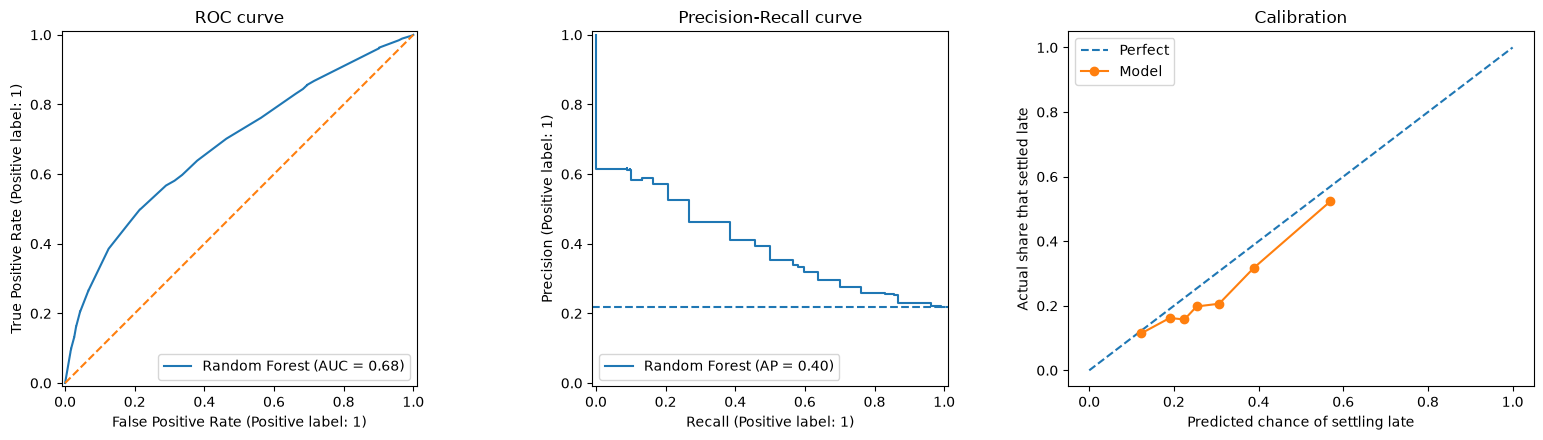

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[0], name=CHOSEN)
axes[0].plot([0, 1], [0, 1], linestyle='--')
PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[1], name=CHOSEN)
axes[1].axhline(y_test.mean(), linestyle='--', label='Baseline')
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=8, strategy='quantile')
axes[2].plot([0, 1], [0, 1], linestyle='--', label='Perfect')
axes[2].plot(mean_pred, frac_pos, marker='o', label='Model')
axes[2].set_xlabel('Predicted chance of settling late')
axes[2].set_ylabel('Actual share that settled late')
axes[2].legend()
axes[0].set_title('ROC curve'); axes[1].set_title('Precision-Recall curve'); axes[2].set_title('Calibration')
plt.tight_layout()
plt.savefig(FIGS + 'behaviour_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Explainability

- SHAP shows how much each feature pushed a prediction up or down.
- The summary plot ranks features across all clients
- The single-client waterfall is what the dashboard's explanation chart will show for one client.
- SHAP runs on the chosen individual model.SHAP shows association, not cause.

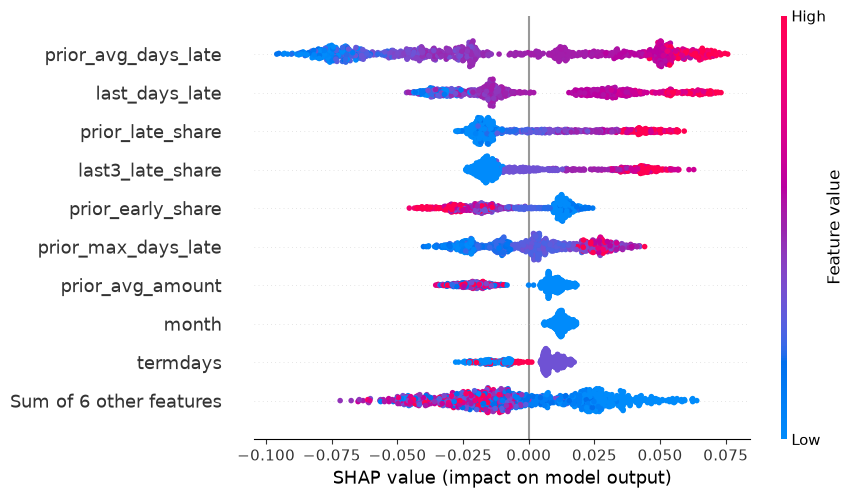

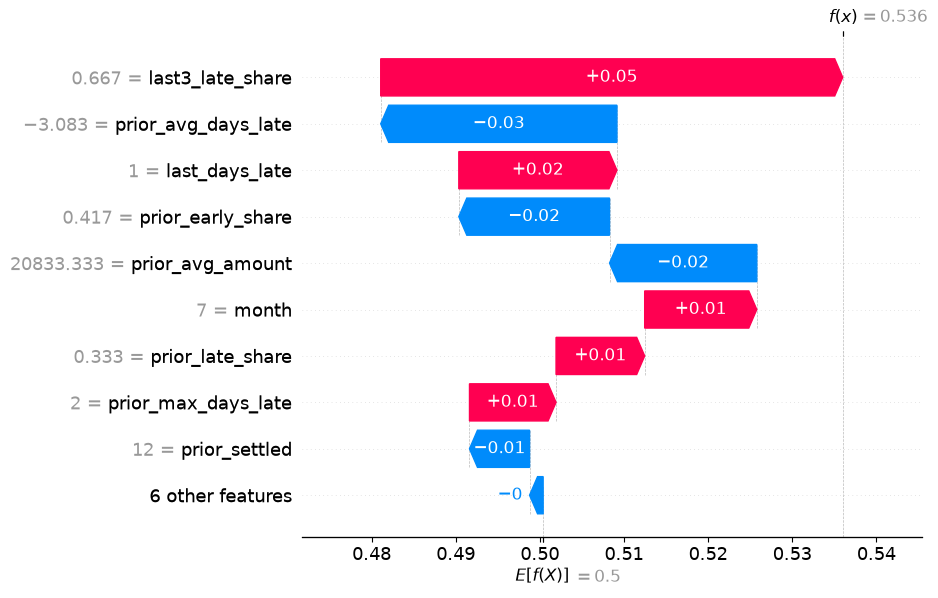

In [22]:
explain_name = 'Random Forest' if CHOSEN in ('Random Forest', 'Average of RF and GB') else 'Gradient Boosting'
explain_model = tuned[explain_name].named_steps['model']
sample = X_test.fillna(-1).sample(1000, random_state=SEED)
sv = shap.TreeExplainer(explain_model)(sample)
if sv.values.ndim == 3:          # Random Forest gives one set per class, keep the 'late' class
    sv = sv[:, :, 1]
shap.plots.beeswarm(sv, show=False)
plt.savefig(FIGS + 'behaviour_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
shap.plots.waterfall(sv[0], show=False)
plt.savefig(FIGS + 'behaviour_shap_one_client.png', dpi=150, bbox_inches='tight')
plt.show()

# Model Persistence

We save the adjusted models, the chosen model's name, the exact feature list and order and the cut-offs in one file. The Python service that Laravel calls will load it. The results and cross validation tables are saved for the report.

In [23]:
joblib.dump({'calibrated_models': calibrated, 'chosen': CHOSEN, 'features': FEATURES,
             'cutoffs': (LOW, HIGH)}, MODELS + 'behaviour_model.joblib')
results.round(4).to_csv(REPORTS + 'behaviour_results.csv')
cv_table.to_csv(REPORTS + 'behaviour_cross_validation.csv')
print('Saved model, results and figures')

Saved model, results and figures


## Results Summary

### Limitations and Diagnostic Findings

- **Data limitation:** The data is Nigerian consumer loans standing in for Kenyan business invoices.
- **Test data limitation:** Only one month of test data is available.
- **High-tier recall:** Recall on the High tier is 0.50, so half of all late payers still land in Low or Medium.

### Academic Statement

A Random Forest with adjusted probabilities, trained only on repayment history, achieved ROC-AUC 0.68 and PR-AUC 0.40 on a held-out later month, against a baseline of 0.22. Averaging it with Gradient Boosting did not improve cross-validated performance and SMOTE did not improve on class weighting.

### Explainability

Recent and average lateness drive the predictions. This is an association, not a cause.

### Business Analysis

In plain words, clients the system flags as High settle late about four times as often as clients it rates Low. An SME can ask them for a deposit or shorter payment terms before extending credit.

### Recommendation

Deploy the Random Forest with adjusted probabilities for clients with three or more settled invoices, and retrain on real Kenyan invoices as the prototype collects them.